# Recovering Experimental Causal Effects

This notebook replicates the core results illustrating our recommended 
best practices from **Section 4** of
*Reevaluating Causal Estimation Methods with Data from a Product Release*
(Young and Dillon, 2026).

**Pipeline:**

| Step | Description | Paper reference |
|------|-------------|-----------------|
| 1 | Load public experimental & observational datasets | §2 |
| 2 | Compute naive difference-in-means | §4 |
| 3 | Estimate propensity scores (ensembled, tuned LGBM) | §4 |
| 4 | Propensity score distributions | Figure 1 |
| 5 | Apply Crump et al. (2009) optimal trimming | §4, Table 2 |
| 6 | Establish experimental ground-truth benchmark | §4 |
| 7 | Fit tuned, ensembled nuisance models (cross-fit) | §4 |
| 8 | Estimate ATE with five methods | §4, Figure 2 |
| 9 | Compare trimmed vs. untrimmed results | §4, Figure 3 |

In [1]:
%pip install -r ../requirements.txt -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

from src.data_loading import load_data, difference_in_means, COVARIATES
from src.propensity import estimate_propensity_ensemble
from src.trimming import optimal_trim_threshold, trim_sample, trim_summary
from src.estimators import (
    regression_ate, outcome_modeling_ate, ipw_ate, psm_ate,
)
from src.utils import ensemble_outcome_models
from src.plotting import plot_propensity_distributions, plot_ate_comparison
from src.cache import load_or_compute, load_pickle
from econml.dr import LinearDRLearner

c:\Users\youngjustin\anaconda3\envs\light_v2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Set `RERUN_ALL = True` to refit everything from scratch using FLAML
AutoML (slow but fully reproducible). When `False` (default), the
notebook loads saved hyperparameters and cross-fits fresh nuisance
models using those configurations. This is much faster than a full AutoML
search while still conducting the estimation procedure on the data.

Set `RUN_PSM = True` to recompute propensity-score matching via R's
`Matching` package. **Note:** PSM with `replace=FALSE, ties=FALSE`
on the trimmed sample (~300k rows) takes ~30 minutes per call and
runs twice (trimmed + untrimmed). When `False` (default), cached PSM
results from `CACHE_DIR` are loaded instead.

In [ ]:
RERUN_ALL = False                 # True → refit everything from scratch via FLAML
RUN_PSM   = False                 # True → recompute PSM via R (~30 min per call); False → load cached

N_MODELS    = 10                  # ensemble members (paper uses 50)
TIME_BUDGET = 100                 # seconds per FLAML run

CACHE_DIR = '../saved_outputs'

print(f"RERUN_ALL = {RERUN_ALL}")
print(f"RUN_PSM   = {RUN_PSM}")
print(f"CACHE_DIR = {CACHE_DIR}")

RERUN_ALL = False
RUN_PSM   = False
CACHE_DIR = ../saved_outputs


---

## 1. Load Data (§2)

In [4]:
observed, experiment = load_data(data_dir='../Data', outcome='continuous')
print(f'Observational sample: {len(observed):,} obs, {observed["D"].sum():,} treated')
print(f'Experimental sample:  {len(experiment):,} obs, {experiment["D"].sum():,} treated')

Observational sample: 445,286 obs, 20,189 treated
Experimental sample:  435,170 obs, 11,475 treated


## 2. Naive Difference-in-Means (§4.1, §4.3)

In [5]:
dm_obs, var_obs = difference_in_means(observed)
dm_exp, var_exp = difference_in_means(experiment)
print(f'Experimental diff-in-means: {dm_exp:.4f} (SE {np.sqrt(var_exp):.4f})')
print(f'Observational diff-in-means: {dm_obs:.4f} (SE {np.sqrt(var_obs):.4f})')

Experimental diff-in-means: 0.4326 (SE 0.0653)
Observational diff-in-means: 1.2077 (SE 0.0571)


## 3. Propensity Score Estimation (§4.4, §4.5)

Ensemble of $N_{Models}$ FLAML-tuned LGBM classifiers, averaged to reduce
model uncertainty.

In [ ]:
W_obs = observed[COVARIATES].values.astype(float)
D_obs = observed['D'].values
y_obs = observed['y'].values

W_exp = experiment[COVARIATES].values.astype(float)
D_exp = experiment['D'].values
y_exp = experiment['y'].values

e_hat_obs = load_or_compute(
    'prop_averaged_FLAML_FINAL_LGBM.pkl',
    lambda: estimate_propensity_ensemble(
        W_obs, D_obs, n_models=N_MODELS, time_budget=TIME_BUDGET),
    rerun=RERUN_ALL,
    cache_dir=CACHE_DIR,
)

# Experimental-sample propensity (used for Figure 1 right panel).
e_hat_exp = load_or_compute(
    'prop_exp_FLAML_FINAL_LGBM.pkl',
    lambda: estimate_propensity_ensemble(
        W_exp, D_exp, n_models=N_MODELS, time_budget=TIME_BUDGET),
    rerun=RERUN_ALL,
    cache_dir=CACHE_DIR,
)

print(f"Propensity scores: obs {e_hat_obs.shape}, exp {e_hat_exp.shape}  "
      f"({'refit' if RERUN_ALL else 'cached'})")


## 4. Propensity Score Distributions: Figure 1

Distribution of $\hat{e}(X)$ in each sample, by treatment status.
The observational sample (left) shows substantial mass near 0 with
poor overlap that motivates the Crump et al. (2009) trimming rule
applied next. The experimental sample (right) is well-balanced, as
expected under randomization.


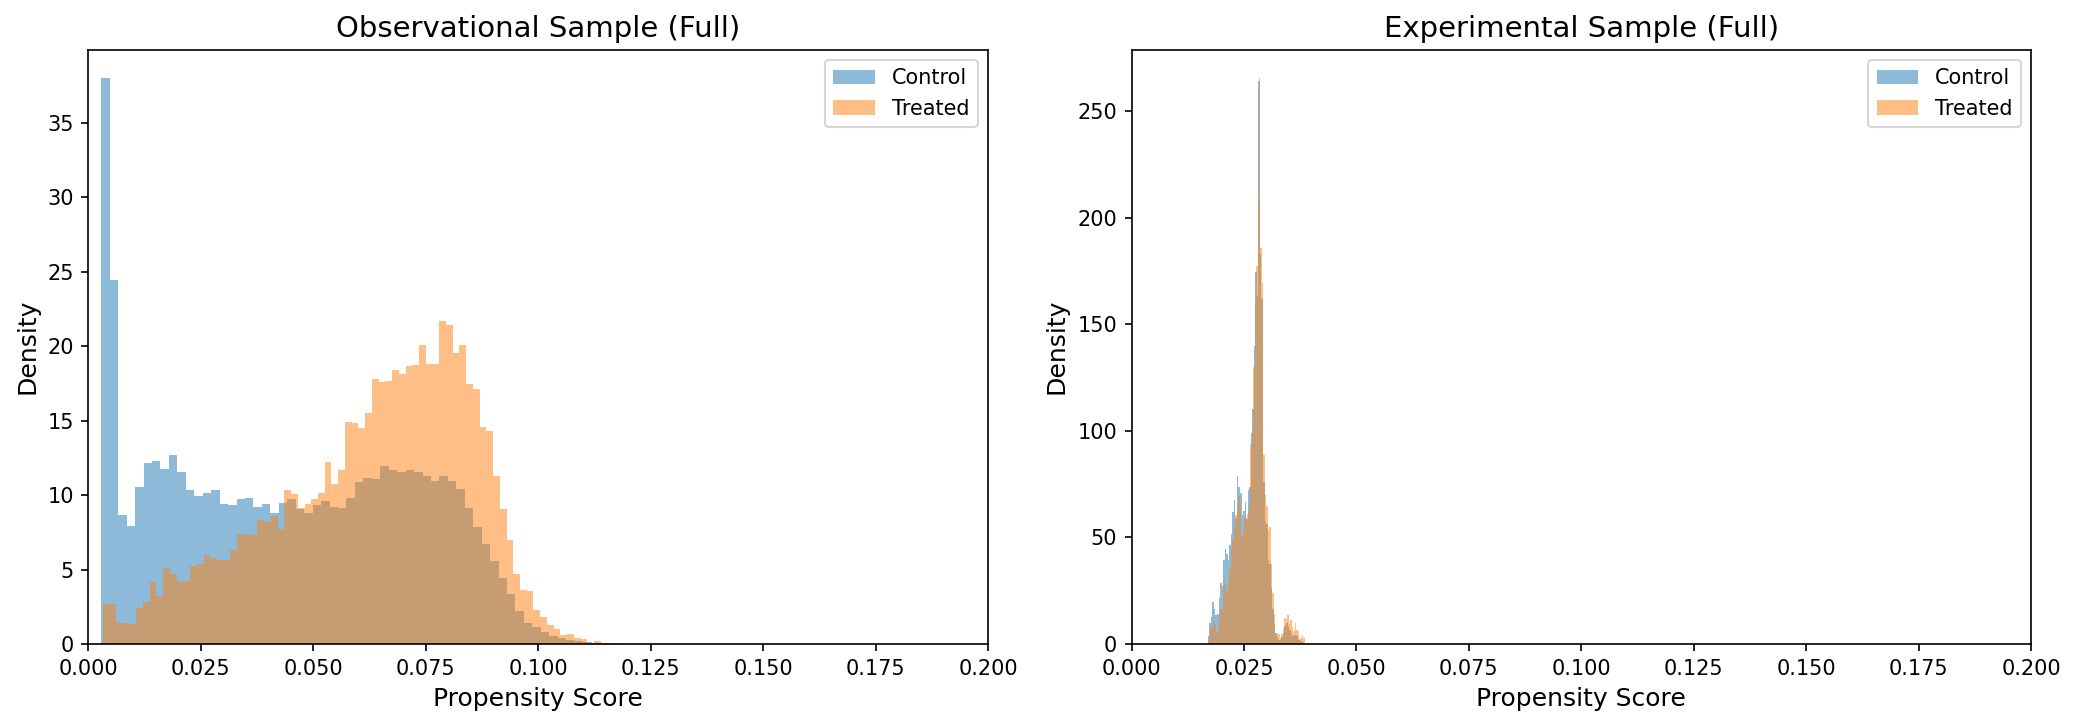

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_propensity_distributions(
    ps_control=e_hat_obs[D_obs == 0],
    ps_treated=e_hat_obs[D_obs == 1],
    title='Observational Sample (Full)',
    ax=axes[0],
)
plot_propensity_distributions(
    ps_control=e_hat_exp[D_exp == 0],
    ps_treated=e_hat_exp[D_exp == 1],
    title='Experimental Sample (Full)',
    ax=axes[1],
)

plt.tight_layout()
plt.show()


## 5. Optimal Trimming: Table 2 (§4.3)

We follow the Crump et al. (2009) rule to select the propensity-score
threshold $\alpha$ that minimizes asymptotic variance, keeping
observations with $\alpha \le \hat{e}(X) \le 1 - \alpha$.


In [8]:
alpha = optimal_trim_threshold(e_hat_obs)
print(f'Optimal trimming threshold: [{alpha:.4f}, {1 - alpha:.4f}]')

obs_trimmed, e_hat_trimmed = trim_sample(observed, e_hat_obs, alpha)
exp_trimmed, e_hat_exp_trimmed = trim_sample(experiment, e_hat_exp, alpha)

summary = trim_summary(
    n_original=len(observed),
    n_trimmed=len(obs_trimmed),
    n_treated_original=int(observed['D'].sum()),
    n_treated_trimmed=int(obs_trimmed['D'].sum()),
)
display(summary)


Optimal trimming threshold: [0.0261, 0.9739]


,Untrimmed,Trimmed,% Dropped
Number of Observations,445286.0,304651.0,0.315831
Number of Treated Units,20189.0,18585.0,0.079449
Number of Control Units,425097.0,286066.0,0.327057


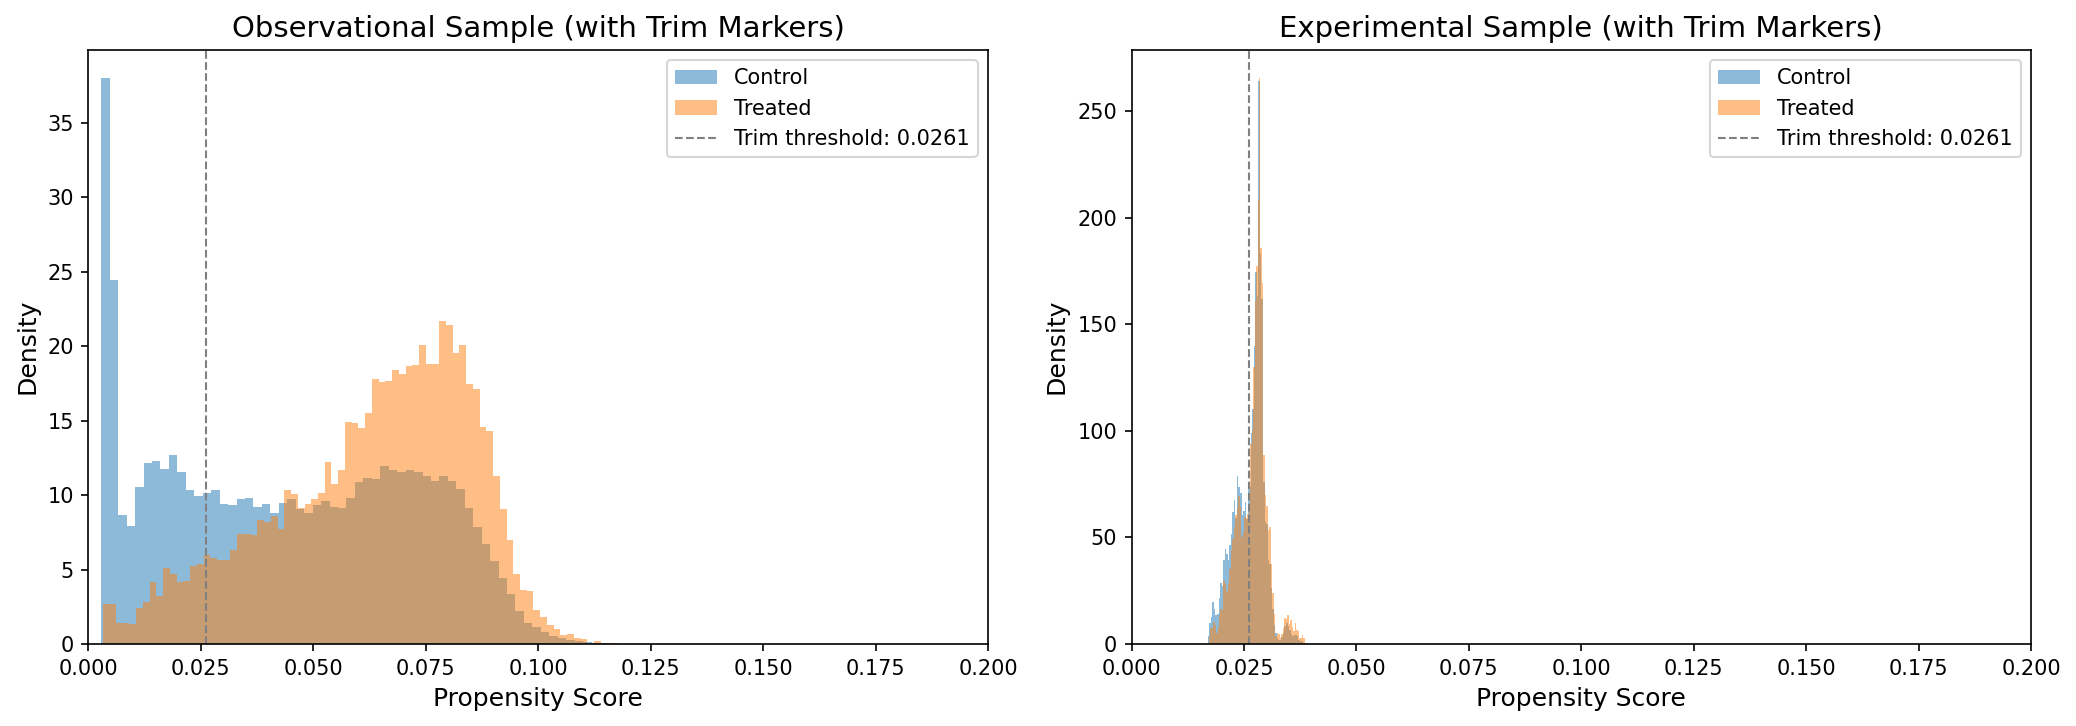

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_propensity_distributions(
    ps_control=e_hat_obs[D_obs == 0],
    ps_treated=e_hat_obs[D_obs == 1],
    title='Observational Sample (with Trim Markers)',
    trim_threshold=alpha,
    ax=axes[0],
)
plot_propensity_distributions(
    ps_control=e_hat_exp[D_exp == 0],
    ps_treated=e_hat_exp[D_exp == 1],
    title='Experimental Sample (with Trim Markers)',
    trim_threshold=alpha,
    ax=axes[1],
)

plt.tight_layout()
plt.show()


## 6. Experimental Benchmark

The ground-truth ATE is the doubly robust estimate on the **trimmed
experimental sample**, using the same $\alpha$ derived from the
observational propensity scores.

| Row | Sample | Description |
|---|---|---|
| **Exp Untrimmed** | Full experimental sample | All randomized units |
| **Exp Trimmed** | $\alpha \le \hat{e}(X) \le 1{-}\alpha$ | Common-support region: the benchmark for Figure 2 |
| **Exp Trimmed Off** | $\hat{e}(X) < \alpha$ | Units outside common support (poor overlap) |


In [10]:
exp_benchmark = load_pickle('exp_dr_ate_FLAML_LGBM_Continuous.pkl', cache_dir=CACHE_DIR)
exp_benchmark = exp_benchmark.rename(index={
    'Exp Left': 'Exp Trimmed Off', 'Exp Right': 'Exp Trimmed'})
display(exp_benchmark[['estimate', 'stderr', 'lower', 'upper']].round(4))

_trim_idx = [i for i in exp_benchmark.index
             if 'trimmed' in i.lower()
             and 'off' not in i.lower()
             and 'untrim' not in i.lower()][0]
_full_idx = [i for i in exp_benchmark.index if 'untrim' in i.lower()][0]

BENCH_EST      = float(exp_benchmark.loc[_trim_idx, 'estimate'])
BENCH_SE       = float(exp_benchmark.loc[_trim_idx, 'stderr'])
BENCH_EST_FULL = float(exp_benchmark.loc[_full_idx,  'estimate'])
BENCH_SE_FULL  = float(exp_benchmark.loc[_full_idx,  'stderr'])

print(f"\nTrimmed benchmark:   {BENCH_EST:.4f}  (SE {BENCH_SE:.4f})")
print(f"Untrimmed benchmark: {BENCH_EST_FULL:.4f}  (SE {BENCH_SE_FULL:.4f})")

,estimate,stderr,lower,upper
Exp Untrimmed,0.2046,0.0587,0.0896,0.3195
Exp Trimmed Off,0.1652,0.0826,0.0032,0.3272
Exp Trimmed,0.2099,0.0774,0.0583,0.3615



Trimmed benchmark:   0.2099  (SE 0.0774)
Untrimmed benchmark: 0.2046  (SE 0.0587)


## 7. Nuisance Model Fitting

A central message of the paper is that **proper nuisance model
tuning and ensembling is critical** for every downstream estimator.
Here we fit the outcome models $\hat\mu_0(X), \hat\mu_1(X)$ and the
propensity model $\hat e(X)$, once using FLAML-tuned LGBM
hyperparameters averaged across multiple seeds and cross-fit on
3 folds, for both the trimmed and untrimmed samples. Sections 8
and 9 then plug these cross-fitted nuisance estimates into the five
estimators.

We also initialize R + the `Matching` package here, which is used
for propensity-score matching in the next section.

In [19]:
import pickle, statsmodels.api as sm
from sklearn.base import clone
from lightgbm import LGBMRegressor, LGBMClassifier
from src.ensemble_wrappers import AveragingRegressor, AveragingClassifier

# ── Trimmed-sample arrays ─────────────────────────────────────────
W_trim = obs_trimmed[COVARIATES].values.astype(float)
D_trim = obs_trimmed['D'].values.astype(float)
y_trim = obs_trimmed['y'].values.astype(float)

# ── Untrimmed-sample arrays ───────────────────────────────────────
D_obs_f = D_obs.astype(float)
n        = len(y_trim)
n_full   = len(y_obs)

CV = KFold(n_splits=3, shuffle=True, random_state=0)

def _clean(params):
    return {k: v for k, v in params.items() if k != 'log_max_bin'}

if RERUN_ALL:
    # ── Trimmed: full FLAML AutoML search ─────────────────────────
    print(f"Fitting {N_MODELS} outcome ensembles via FLAML (trimmed)...")
    mu0_hat, mu1_hat = ensemble_outcome_models(
        W_trim, y_trim, D_trim, n_models=N_MODELS, time_budget=TIME_BUDGET)
    print(f"Fitting {N_MODELS} propensity models via FLAML (trimmed)...")
    e_hat_cf = estimate_propensity_ensemble(
        W_trim, D_trim.astype(int), n_models=N_MODELS, time_budget=TIME_BUDGET)
    # ── Untrimmed: full FLAML AutoML search ───────────────────────
    print(f"Fitting {N_MODELS} outcome ensembles via FLAML (untrimmed)...")
    mu0_full, mu1_full = ensemble_outcome_models(
        W_obs, y_obs, D_obs, n_models=N_MODELS, time_budget=TIME_BUDGET)
    print(f"Fitting {N_MODELS} propensity models via FLAML (untrimmed)...")
    e_hat_full_cf = estimate_propensity_ensemble(
        W_obs, D_obs.astype(int), n_models=N_MODELS, time_budget=TIME_BUDGET)
    hp_y0 = hp_y1 = hp_prop = hp_y0_full = hp_y1_full = None
else:
    # ── Load saved FLAML hyperparameters ──────────────────────────
    def _load_params(name):
        with open(f'{CACHE_DIR}/{name}', 'rb') as f:
            return pickle.load(f)

    hp_y0      = _load_params('right_modely0_obs_hyperparams.pkl')
    hp_y1      = _load_params('right_modely1_obs_hyperparams.pkl')
    hp_prop    = _load_params('propensity_hyperparams.pkl')
    hp_y0_full = _load_params('untrimmed_modely0_obs_hyperparams.pkl')
    hp_y1_full = _load_params('untrimmed_modely1_obs_hyperparams.pkl')

    # ── Build averaging ensembles from saved hyperparameters ──────
    model_y0 = AveragingRegressor(
        estimators=[LGBMRegressor(**_clean(p), verbosity=-1) for p in hp_y0])
    model_y1 = AveragingRegressor(
        estimators=[LGBMRegressor(**_clean(p), verbosity=-1) for p in hp_y1])
    model_ps = AveragingClassifier(
        estimators=[LGBMClassifier(**_clean(p), verbosity=-1) for p in hp_prop])
    model_y0_full = AveragingRegressor(
        estimators=[LGBMRegressor(**_clean(p), verbosity=-1) for p in hp_y0_full])
    model_y1_full = AveragingRegressor(
        estimators=[LGBMRegressor(**_clean(p), verbosity=-1) for p in hp_y1_full])
    print(f"Built ensembles; trimmed: y0 ({len(hp_y0)}), y1 ({len(hp_y1)}), "
          f"propensity ({len(hp_prop)}); untrimmed: y0 ({len(hp_y0_full)}), "
          f"y1 ({len(hp_y1_full)})")

    # ── Cross-fit on trimmed sample ───────────────────────────────
    mu0_hat  = np.zeros(n)
    mu1_hat  = np.zeros(n)
    e_hat_cf = np.zeros(n)
    for tr, te in CV.split(W_trim):
        mu0_hat[te]  = clone(model_y0).fit(
            W_trim[tr][D_trim[tr]==0], y_trim[tr][D_trim[tr]==0]).predict(W_trim[te])
        mu1_hat[te]  = clone(model_y1).fit(
            W_trim[tr][D_trim[tr]==1], y_trim[tr][D_trim[tr]==1]).predict(W_trim[te])
        e_hat_cf[te] = clone(model_ps).fit(
            W_trim[tr], D_trim[tr].astype(int)).predict_proba(W_trim[te])[:, 1]

    # ── Cross-fit on untrimmed sample ─────────────────────────────
    mu0_full      = np.zeros(n_full)
    mu1_full      = np.zeros(n_full)
    e_hat_full_cf = np.zeros(n_full)
    for tr, te in CV.split(W_obs):
        mu0_full[te]      = clone(model_y0_full).fit(
            W_obs[tr][D_obs_f[tr]==0], y_obs[tr][D_obs_f[tr]==0]).predict(W_obs[te])
        mu1_full[te]      = clone(model_y1_full).fit(
            W_obs[tr][D_obs_f[tr]==1], y_obs[tr][D_obs_f[tr]==1]).predict(W_obs[te])
        e_hat_full_cf[te] = clone(model_ps).fit(
            W_obs[tr], D_obs[tr].astype(int)).predict_proba(W_obs[te])[:, 1]

print(f"Cross-fitted trimmed:   mu0 {mu0_hat.shape},  mu1 {mu1_hat.shape},  e {e_hat_cf.shape}")
print(f"Cross-fitted untrimmed: mu0 {mu0_full.shape}, mu1 {mu1_full.shape}, e {e_hat_full_cf.shape}")

# ── Set up R for PSM ──────────────────────────────────────────────
_R_AVAILABLE = False

def _pick_r_home():
    if os.environ.get('R_HOME'):
        return os.environ['R_HOME']
    for _root in [r'C:\Program Files\R', '/usr/lib/R', '/usr/local/lib/R']:
        if os.path.isdir(_root):
            if 'Program Files' in _root:
                # Prefer a version whose library/base exists (some installs are broken).
                for v in sorted(os.listdir(_root), reverse=True):
                    cand = os.path.join(_root, v)
                    if os.path.isdir(os.path.join(cand, 'library', 'base')):
                        return cand
            else:
                return _root
    return None

_R_HOME = _pick_r_home()
if _R_HOME:
    os.environ['R_HOME'] = _R_HOME
    # Put R's DLLs ahead of conda env DLLs so stats.dll etc. load cleanly.
    _r_bin_x64 = os.path.join(_R_HOME, 'bin', 'x64')
    _r_bin     = os.path.join(_R_HOME, 'bin')
    os.environ['PATH'] = _r_bin_x64 + os.pathsep + _r_bin + os.pathsep + os.environ.get('PATH', '')
    if hasattr(os, 'add_dll_directory') and os.path.isdir(_r_bin_x64):
        try:
            os.add_dll_directory(_r_bin_x64)
        except Exception:
            pass
    # Use a writable user library so install.packages works without prompting.
    _user_lib = os.path.join(os.path.expanduser('~'), 'R', 'win-library',
                             os.path.basename(_R_HOME).replace('R-', '').rsplit('.', 1)[0])
    os.makedirs(_user_lib, exist_ok=True)
    os.environ.setdefault('R_LIBS_USER', _user_lib)

try:
    import rpy2.robjects as ro
    from rpy2.robjects import numpy2ri, conversion, default_converter
    ro.r('''
        if (!requireNamespace("Matching", quietly=TRUE))
            install.packages("Matching", repos="https://cran.r-project.org", quiet=TRUE)
        suppressPackageStartupMessages(library(Matching))
    ''')
    _R_AVAILABLE = True
    print(f"R + Matching loaded (R_HOME={os.environ.get('R_HOME')})")
except Exception as _e:
    _R_AVAILABLE = False
    print(f"R not available ({_e}); PSM will use cached results")

def _psm_via_r(y, D, e_hat):
    with conversion.localconverter(default_converter + numpy2ri.converter):
        ro.globalenv['y_r']  = ro.FloatVector(y)
        ro.globalenv['D_r']  = ro.IntVector(D.astype(int))
        ro.globalenv['ps_r'] = ro.FloatVector(e_hat)
        r_out = ro.r('''
            m <- Match(Y=y_r, Tr=D_r, X=matrix(ps_r, length(ps_r), 1),
                       estimand="ATE", M=1, replace=FALSE, ties=FALSE,
                       BiasAdjust=FALSE)
            se <- ifelse(!is.null(m$se), m$se[1], m$se.standard[1])
            c(m$est[1], se, m$est[1] - 1.96*se, m$est[1] + 1.96*se)
        ''')
    return tuple(float(x) for x in r_out)

Built ensembles; trimmed: y0 (10), y1 (10), propensity (10); untrimmed: y0 (10), y1 (10)
Cross-fitted trimmed:   mu0 (304651,),  mu1 (304651,),  e (304651,)
Cross-fitted untrimmed: mu0 (445286,), mu1 (445286,), e (445286,)
R + Matching loaded (R_HOME=C:/PROGRA~1/R/R-46~1.0)


## 8. ATE Estimation: Trimmed Sample (Figure 2)

Five estimators: OLS **Regression**, **Outcome Modeling**,
**Inverse Probability Weighting**, **Propensity Score Matching**, and
**Doubly Robust** cross-fit AIPW. OM, IPW, and PSM plug in the
cross-fitted nuisance estimates from Section 7 directly.

> **Note on some notebook redundancy:** EconML's `LinearDRLearner` manages its own
> internal K-fold cross-fitting and does not accept pre-computed
> nuisance estimates, so the DR row re-fits its own nuisance models
> here. This is duplicative with Section 7 but harmless. 

All standard errors are analytic. While all five estimators achieve
the semiparametric efficiency bound asymptotically (Hahn 1998), IPW
can exhibit inflated finite-sample variance when treatment is rare.
Bootstrap standard errors can provide a more stable alternative for
IPW in these settings.

In [15]:
# ── Helper ─────────────────────────────────────────────────────────

def _row(tag, est, se):
    lo, hi = est - 1.96*se, est + 1.96*se
    print(f"  {tag:4s}  {est:+.4f}  (SE {se:.4f})")
    return dict(Estimator=tag, Estimate=est, SE=se,
                CI_Lower=lo, CI_Upper=hi)

# ── Trimmed: all five estimators ──────────────────────────────────

print('── Trimmed sample ──')
rows = []

# Reg: OLS + HC1
X_reg = sm.add_constant(np.column_stack([D_trim, W_trim]))
ols = sm.OLS(y_trim, X_reg).fit(cov_type='HC1')
rows.append(_row('Reg', float(ols.params[1]), float(ols.bse[1])))

# OM: Guo-Basse SE
om_est = float(np.mean(mu1_hat - mu0_hat))
t_idx, c_idx = D_trim == 1, D_trim == 0
om_se = float(np.sqrt(
    np.mean((y_trim[t_idx]-mu1_hat[t_idx])**2) / t_idx.sum() +
    np.mean((y_trim[c_idx]-mu0_hat[c_idx])**2) / c_idx.sum()))
rows.append(_row('OM', om_est, om_se))

# IPW: influence-function SE
psi = D_trim*y_trim/e_hat_cf - (1-D_trim)*y_trim/(1-e_hat_cf)
rows.append(_row('IPW', float(np.mean(psi)),
                 float(np.std(psi, ddof=1)/np.sqrt(n))))

# PSM placeholder (index 3)
rows.append(None)

# DR: EconML
if RERUN_ALL:
    dr = LinearDRLearner(
        model_regression=LGBMRegressor(verbosity=-1),
        model_propensity=LGBMClassifier(verbosity=-1),
        cv=CV, min_propensity=0.01, random_state=0)
else:
    dr = LinearDRLearner(
        model_regression=LGBMRegressor(**_clean(hp_y0[0]), verbosity=-1),
        model_propensity=LGBMClassifier(**_clean(hp_prop[0]), verbosity=-1),
        cv=CV, min_propensity=0.01, random_state=0)
dr.fit(y_trim, D_trim, W=W_trim)
inf = dr.ate_inference()
ci = inf.conf_int_mean()
est = float(dr.ate())
se = float(inf.stderr_mean)
lo = float(ci[0]) if hasattr(ci[0], '__float__') else float(ci[0][0])
hi = float(ci[1]) if hasattr(ci[1], '__float__') else float(ci[1][0])
rows.append(dict(Estimator='DR', Estimate=est, SE=se,
                 CI_Lower=lo, CI_Upper=hi))
print(f"  DR    {est:+.4f}  (SE {se:.4f})")

# PSM via R (slow!) or cached
if RUN_PSM and _R_AVAILABLE:
    print('  PSM   running via R (this may take ~30 min on the trimmed sample)...')
    psm_est, psm_se, psm_lo, psm_hi = _psm_via_r(y_trim, D_trim, e_hat_cf)
    rows[3] = dict(Estimator='PSM', Estimate=psm_est, SE=psm_se,
                   CI_Lower=psm_lo, CI_Upper=psm_hi)
    print(f"  PSM   {psm_est:+.4f}  (SE {psm_se:.4f})")
else:
    _psm = load_pickle('TRIMMED_ate_psm_pass_noreplace.pkl', cache_dir=CACHE_DIR)
    _v = np.array(_psm).flatten()
    rows[3] = dict(Estimator='PSM', Estimate=float(_v[0]), SE=float(_v[1]),
                   CI_Lower=float(_v[2]), CI_Upper=float(_v[3]))
    _why = 'RUN_PSM=False' if not RUN_PSM else 'R unavailable'
    print(f"  PSM   {float(_v[0]):+.4f}  (SE {float(_v[1]):.4f})  [cached: {_why}]")

results_trimmed = pd.DataFrame(rows)
display(results_trimmed.round(4))

── Trimmed sample ──
  Reg   +0.2823  (SE 0.0578)
  OM    +0.2336  (SE 0.0569)
  IPW   +0.2060  (SE 0.0712)
  DR    +0.1989  (SE 0.0561)
  PSM   +0.3391  (SE 0.0571)  [cached: RUN_PSM=False]


,Estimator,Estimate,SE,CI_Lower,CI_Upper
0,Reg,0.2823,0.0578,0.1689,0.3956
1,OM,0.2336,0.0569,0.1221,0.3452
2,IPW,0.2060,0.0712,0.0664,0.3456
3,PSM,0.3391,0.0571,0.2271,0.4510
4,DR,0.1989,0.0561,0.0890,0.3088


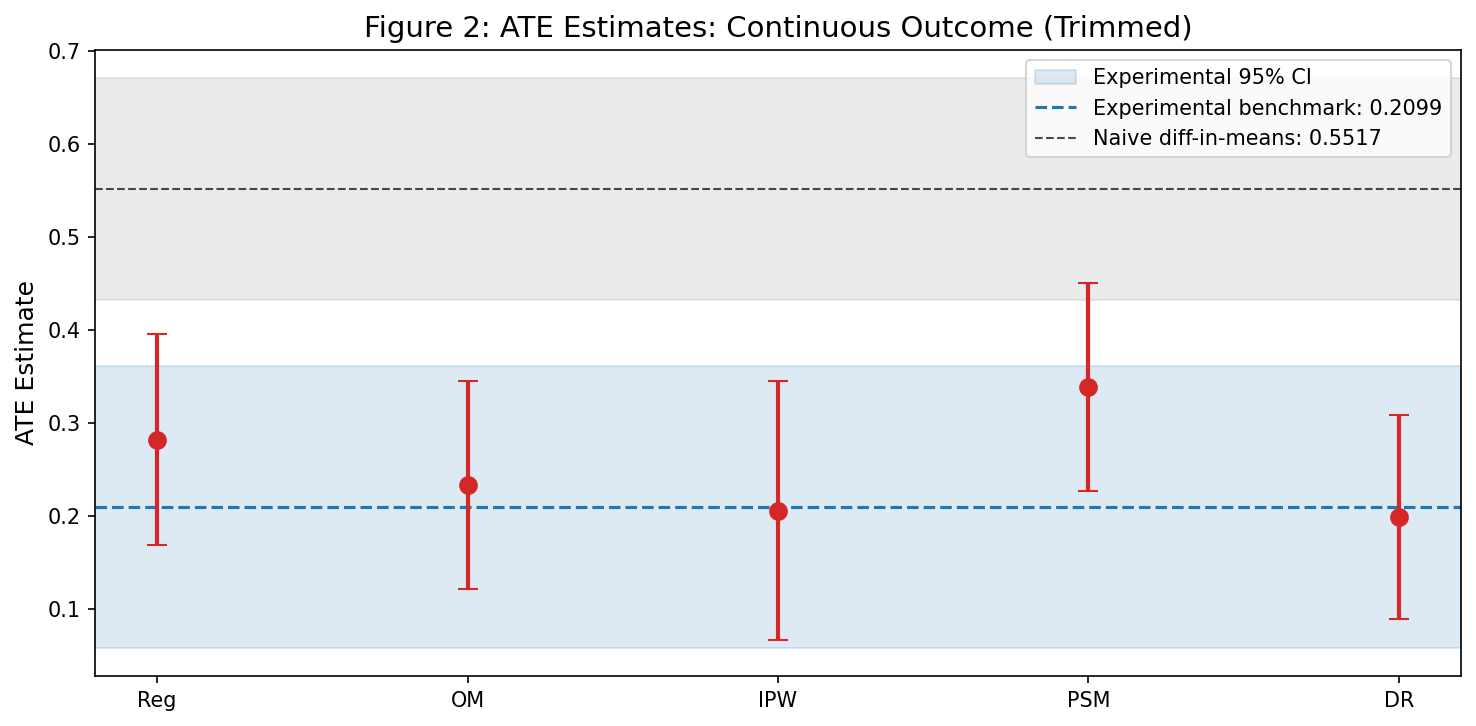

In [17]:
dm_obs_trim, var_obs_trim = difference_in_means(obs_trimmed)

fig, ax = plt.subplots(figsize=(10, 5))
plot_ate_comparison(
    results_trimmed,
    benchmark_est=BENCH_EST, benchmark_se=BENCH_SE,
    naive_est=dm_obs_trim, naive_se=np.sqrt(var_obs_trim),
    title='Figure 2: ATE Estimates: Continuous Outcome (Trimmed)',
    ax=ax,
)
plt.tight_layout()
plt.show()

## 9. Untrimmed Comparison: Figure 3

Without trimming, many estimators are biased upward from the
experimental benchmark.

── Untrimmed sample ──
  Reg   +0.3255  (SE 0.0545)
  OM    +0.3311  (SE 0.0532)
  IPW   +0.1917  (SE 0.0720)
  PSM   +0.7433  (SE 0.0528)  [cached: RUN_PSM=False]
  DR    +0.2215  (SE 0.0502)


,Estimator,Estimate,SE,CI_Lower,CI_Upper
0,Reg,0.3255,0.0545,0.2187,0.4323
1,OM,0.3311,0.0532,0.2268,0.4354
2,IPW,0.1917,0.0720,0.0505,0.3329
3,PSM,0.7433,0.0528,0.6399,0.8468
4,DR,0.2215,0.0502,0.1230,0.3199


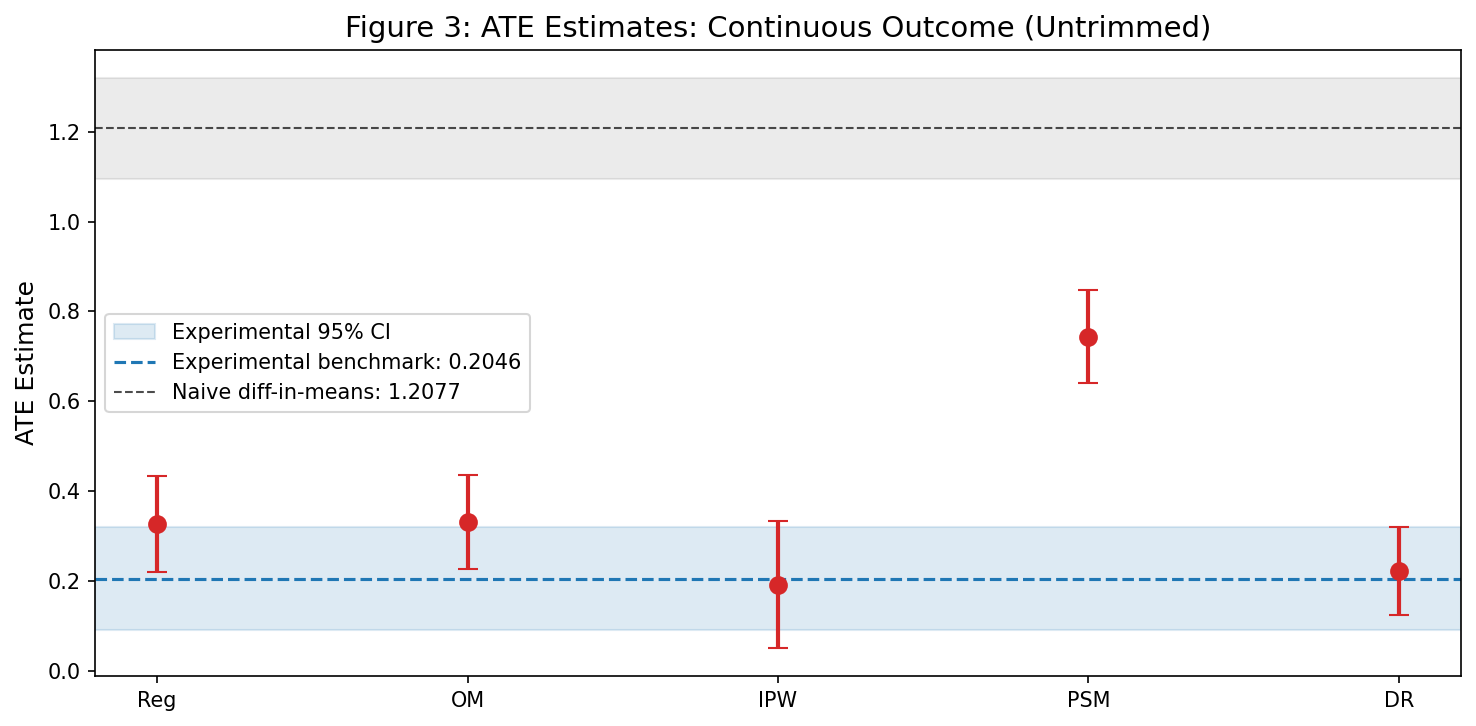

In [18]:
# ── Untrimmed: all five estimators ─────────────────────────────────
print('── Untrimmed sample ──')
rows_full = []

X_reg_f = sm.add_constant(np.column_stack([D_obs_f, W_obs]))
ols_f = sm.OLS(y_obs, X_reg_f).fit(cov_type='HC1')
rows_full.append(_row('Reg', float(ols_f.params[1]), float(ols_f.bse[1])))

om_est_f = float(np.mean(mu1_full - mu0_full))
t_f, c_f = D_obs_f == 1, D_obs_f == 0
om_se_f = float(np.sqrt(
    np.mean((y_obs[t_f]-mu1_full[t_f])**2)/t_f.sum() +
    np.mean((y_obs[c_f]-mu0_full[c_f])**2)/c_f.sum()))
rows_full.append(_row('OM', om_est_f, om_se_f))

psi_f = D_obs_f*y_obs/e_hat_full_cf - (1-D_obs_f)*y_obs/(1-e_hat_full_cf)
rows_full.append(_row('IPW', float(np.mean(psi_f)),
                      float(np.std(psi_f, ddof=1)/np.sqrt(n_full))))

# PSM via R (slow!) or cached
if RUN_PSM and _R_AVAILABLE:
    print('  PSM   running via R (this may take ~30 min on the untrimmed sample)...')
    pe, ps, pl, ph = _psm_via_r(y_obs, D_obs_f, e_hat_full_cf)
    rows_full.append(dict(Estimator='PSM', Estimate=pe, SE=ps,
                          CI_Lower=pl, CI_Upper=ph))
    print(f"  PSM   {pe:+.4f}  (SE {ps:.4f})")
else:
    _psm_full = load_pickle('UNTRIMMED_ate_psm_pass_noreplace.pkl', cache_dir=CACHE_DIR)
    _v = np.array(_psm_full).flatten()
    rows_full.append(dict(Estimator='PSM', Estimate=float(_v[0]), SE=float(_v[1]),
                          CI_Lower=float(_v[2]), CI_Upper=float(_v[3])))
    _why = 'RUN_PSM=False' if not RUN_PSM else 'R unavailable'
    print(f"  PSM   {float(_v[0]):+.4f}  (SE {float(_v[1]):.4f})  [cached: {_why}]")

# DR
if RERUN_ALL:
    dr_f = LinearDRLearner(
        model_regression=LGBMRegressor(verbosity=-1),
        model_propensity=LGBMClassifier(verbosity=-1),
        cv=CV, min_propensity=0.01, random_state=0)
else:
    dr_f = LinearDRLearner(
        model_regression=LGBMRegressor(**_clean(hp_y0_full[0]), verbosity=-1),
        model_propensity=LGBMClassifier(**_clean(hp_prop[0]), verbosity=-1),
        cv=CV, min_propensity=0.01, random_state=0)
dr_f.fit(y_obs, D_obs_f, W=W_obs)
inf_f = dr_f.ate_inference()
ci_f = inf_f.conf_int_mean()
est = float(dr_f.ate())
se = float(inf_f.stderr_mean)
lo = float(ci_f[0]) if hasattr(ci_f[0], '__float__') else float(ci_f[0][0])
hi = float(ci_f[1]) if hasattr(ci_f[1], '__float__') else float(ci_f[1][0])
rows_full.append(dict(Estimator='DR', Estimate=est, SE=se,
                      CI_Lower=lo, CI_Upper=hi))
print(f"  DR    {est:+.4f}  (SE {se:.4f})")

results_full = pd.DataFrame(rows_full)
display(results_full.round(4))

# ── Figure 3 ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
plot_ate_comparison(
    results_full,
    benchmark_est=BENCH_EST_FULL, benchmark_se=BENCH_SE_FULL,
    naive_est=dm_obs, naive_se=np.sqrt(var_obs),
    title='Figure 3: ATE Estimates: Continuous Outcome (Untrimmed)',
    ax=ax,
)
plt.tight_layout()
plt.show()

---

## Key Takeaways

Extending the findings of LaLonde (1986), we have introduced and analyzed a new paired observational-experimental dataset, which allowed us to test treatment effect estimation across the _entire_ distribution of individuals. Our key findings include:

1. **Trimming matters** for recovery of the experimental benchmark. 
2. **Nuisance model tuning** is critical. Furthermore, **ensembling** reduces model uncertainty. 
3.  **All five estimators** recover the experimental benchmark within
   95% CIs after trimming, nuisance tuning, and ensembling (Figure 2).